In [1]:
import pandas as pd

sample_df = pd.read_csv("../data/processed/events_sample.csv")

sample_df["event_time"] = pd.to_datetime(sample_df["event_time"])

print(sample_df.shape)

(675019, 9)


In [2]:
# Event Distribution : What are users doing?
sample_df["event_type"].value_counts()

event_type
view        635782
cart         30295
purchase      8942
Name: count, dtype: int64

In [3]:
# Unique Users : How many users generated these events?
sample_df["user_id"].nunique()

473566

In [4]:
# Product Diversity : Is engagement concentrated in a few products?
sample_df["product_id"].nunique()

78181

In [5]:
# Category Diversity : How broad is the catalog?
sample_df["category_id"].nunique()

656

In [6]:
# Brand Diversity : Is marketplace traffic dominated by a few brands?
sample_df["brand"].nunique()

3179

In [7]:
# Price Analysis : Are users engaging with low-price or premium products?
sample_df["price"].describe()

count    675019.000000
mean        292.719761
std         356.949592
min           0.000000
25%          69.240000
50%         165.840000
75%         360.340000
max        2574.070000
Name: price, dtype: float64

In [8]:
# Daily Event Trend : Which days have highest activity?
sample_df["date"] = sample_df["event_time"].dt.date

daily_events = (
    sample_df.groupby("date")
    .size()
    .reset_index(name="events")
)

daily_events.head()

,date,events
0,2019-11-01,14453
1,2019-11-02,15555
2,2019-11-03,15678
3,2019-11-04,17932
4,2019-11-05,17172


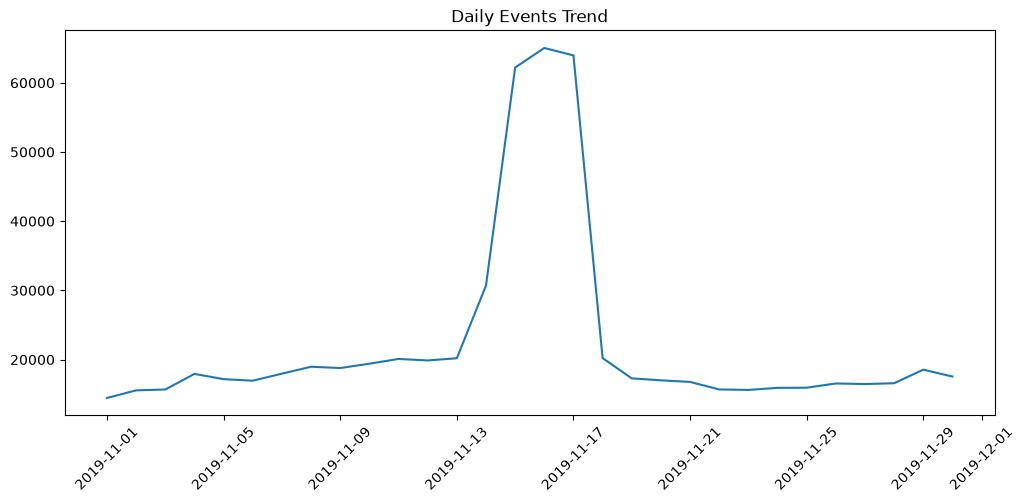

In [9]:
# Daily Events Trend
import matplotlib.pyplot as plt

daily_events = (
    sample_df.groupby(sample_df["event_time"].dt.date)
    .size()
    .reset_index(name="events")
)

plt.figure(figsize=(12,5))
plt.plot(daily_events["event_time"], daily_events["events"])
plt.title("Daily Events Trend")
plt.xticks(rotation=45)
plt.savefig("../outputs/daily_events_trend.png", bbox_inches="tight")
plt.show()

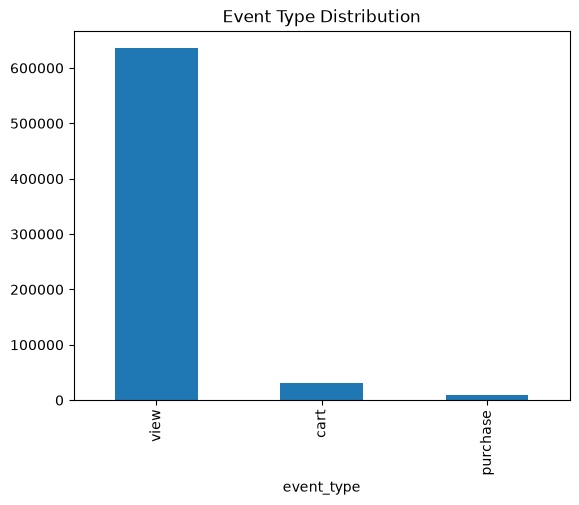

In [10]:
# Event Distribution Chart
sample_df["event_type"].value_counts().plot(
    kind="bar"
)

plt.title("Event Type Distribution")
plt.savefig("../outputs/event_type_distribution.png", bbox_inches="tight")
plt.show()

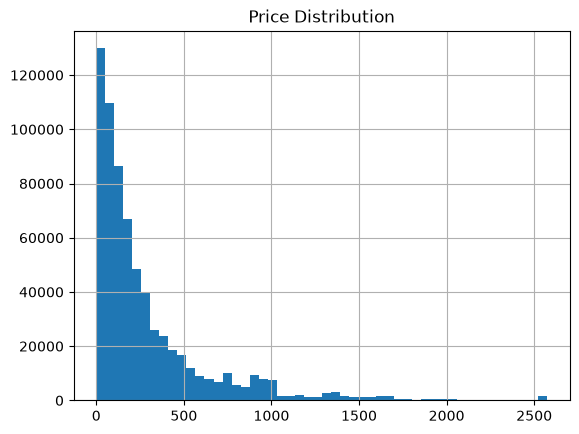

In [11]:
# Price Distribution
sample_df["price"].hist(
    bins=50
)

plt.title("Price Distribution")
plt.savefig("../outputs/price_distribution.png", bbox_inches="tight")
plt.show()

In [12]:
event_distribution = pd.DataFrame({
    "event_type": [
        "View",
        "Cart",
        "Purchase"
    ],
    "count": [
        635782,
        30295,
        8942
    ]
})

event_distribution.to_csv(
    "../powerbi/datasets/event_distribution.csv",
    index=False
)